# Data Preprocessing

## 1. Load Datase and Inspect

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

sys.path.append(
    str(PROJECT_ROOT)
)

In [3]:
from src.data.ingestion import load_raw_data
from src.data.preprocessing import preprocess_data
from src.data.validation import validate_dataset

In [4]:
#Load the dataset using your new ingestion module 
RAW_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "household_power_consumption.txt"
)

df = load_raw_data(
    RAW_DATA_PATH
)

print(
    "Raw dataset shape:",
    df.shape
)

Raw dataset shape: (2075259, 9)


In [5]:
# Find the project root correctly
PROJECT_ROOT = Path.cwd().parent

print("Project root:")
print(PROJECT_ROOT)

Project root:
c:\Users\sayum\Desktop\smartenergy-ai


In [6]:
# Define the path to the raw data file
RAW_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "household_power_consumption.txt"
)

print("Raw data path:")
print(RAW_DATA_PATH)

Raw data path:
c:\Users\sayum\Desktop\smartenergy-ai\data\raw\household_power_consumption.txt


In [7]:
# Check that the file exists
if not RAW_DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found: {RAW_DATA_PATH}"
    )

print("Dataset found successfully.")

Dataset found successfully.


In [8]:
# Load the raw dataset
df = pd.read_csv(
    RAW_DATA_PATH,
    sep=";",
    low_memory=False
)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [9]:
# Inspect the first records

display(df.head()) # Inspect the first records
display(df.tail()) # Inspect the last records
display(df.head().T) # Transpose the first few records for better readability

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
2075254,26/11/2010,20:58:00,0.946,0.000,240.430,4.000,0.000,0.000,0.0
2075255,26/11/2010,20:59:00,0.944,0.000,240.000,4.000,0.000,0.000,0.0
2075256,26/11/2010,21:00:00,0.938,0.000,239.820,3.800,0.000,0.000,0.0
2075257,26/11/2010,21:01:00,0.934,0.000,239.700,3.800,0.000,0.000,0.0
2075258,26/11/2010,21:02:00,0.932,0.000,239.550,3.800,0.000,0.000,0.0


,0,1,2,3,4
Date,16/12/2006,16/12/2006,16/12/2006,16/12/2006,16/12/2006
Time,17:24:00,17:25:00,17:26:00,17:27:00,17:28:00
Global_active_power,4.216,5.360,5.374,5.388,3.666
Global_reactive_power,0.418,0.436,0.498,0.502,0.528
Voltage,234.840,233.630,233.290,233.740,235.680
Global_intensity,18.400,23.000,23.000,23.000,15.800
Sub_metering_1,0.000,0.000,0.000,0.000,0.000
Sub_metering_2,1.000,1.000,2.000,1.000,1.000
Sub_metering_3,17.0,16.0,17.0,17.0,17.0


In [10]:
# Check the dataset dimensions

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 2075259
Number of columns: 9


In [11]:
print("Columns:") 
for column in df.columns:
    print(f" - {column}")

Columns:
 - Date
 - Time
 - Global_active_power
 - Global_reactive_power
 - Voltage
 - Global_intensity
 - Sub_metering_1
 - Sub_metering_2
 - Sub_metering_3


In [12]:
# Check data types
print(df.dtypes)  # The raw dataset needs preprocessing.

Date                         str
Time                         str
Global_active_power          str
Global_reactive_power        str
Voltage                      str
Global_intensity             str
Sub_metering_1               str
Sub_metering_2               str
Sub_metering_3           float64
dtype: object


## 2. MISSING VALUES

In [13]:
# Missing-value report
missing_count = df.isna().sum()

missing_percentage = (
    df.isna().mean() * 100
).round(2)

missing_report = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percentage": missing_percentage
})

display(
    missing_report.sort_values(
        "missing_percentage",
        ascending=False
    )
)

,missing_count,missing_percentage
Sub_metering_3,25979,1.25
Date,0,0.00
Time,0,0.00
Global_reactive_power,0,0.00
Global_active_power,0,0.00
Voltage,0,0.00
Global_intensity,0,0.00
Sub_metering_1,0,0.00
Sub_metering_2,0,0.00


In [14]:
# Check duplicate rows
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


## 3. Create timestamp

In [15]:
df["timestamp"] = pd.to_datetime( 
    df["Date"].astype(str) + " " + df["Time"].astype(str),
    errors="coerce"
)

C:\Users\sayum\AppData\Local\Temp\ipykernel_20484\2845618200.py:1: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["timestamp"] = pd.to_datetime(


In [16]:
# Display the first 10 rows of the DataFrame with the new timestamp column
display(
    df[
        ["Date", "Time", "timestamp"]
    ].head(10)
)

,Date,Time,timestamp
0,16/12/2006,17:24:00,2006-12-16 17:24:00
1,16/12/2006,17:25:00,2006-12-16 17:25:00
2,16/12/2006,17:26:00,2006-12-16 17:26:00
3,16/12/2006,17:27:00,2006-12-16 17:27:00
4,16/12/2006,17:28:00,2006-12-16 17:28:00
5,16/12/2006,17:29:00,2006-12-16 17:29:00
6,16/12/2006,17:30:00,2006-12-16 17:30:00
7,16/12/2006,17:31:00,2006-12-16 17:31:00
8,16/12/2006,17:32:00,2006-12-16 17:32:00
9,16/12/2006,17:33:00,2006-12-16 17:33:00


## 4. Check invalid timestamps

In [17]:

invalid_timestamp_count = df["timestamp"].isna().sum()

print(
    "Invalid timestamps:",
    invalid_timestamp_count
)

Invalid timestamps: 0


## 5. Convert measurement columns

In [18]:
# List of columns to convert to numeric type
NUMERIC_COLUMNS = [ 
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]

In [19]:
# Convert columns to numeric type
for column in NUMERIC_COLUMNS: 
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )
print(df[NUMERIC_COLUMNS].dtypes)

Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object


## 6. Check missing values again

In [20]:
missing_count = df.isna().sum()

missing_percentage = (
    df.isna().mean() * 100
).round(2)

missing_report = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percentage": missing_percentage
})

display(
    missing_report.sort_values(
        "missing_count",
        ascending=False
    )
)

,missing_count,missing_percentage
Global_reactive_power,25979,1.25
Global_active_power,25979,1.25
Sub_metering_1,25979,1.25
Sub_metering_2,25979,1.25
Voltage,25979,1.25
Global_intensity,25979,1.25
Sub_metering_3,25979,1.25
Date,0,0.00
Time,0,0.00
timestamp,0,0.00


## 7. Check numeric statistics

In [21]:
display(
    df[NUMERIC_COLUMNS].describe().T
)

,count,mean,std,min,25%,50%,75%,max
Global_active_power,2049280.0,1.091615,1.057294,0.076,0.308,0.602,1.528,11.122
Global_reactive_power,2049280.0,0.123714,0.112722,0.000,0.048,0.100,0.194,1.390
Voltage,2049280.0,240.839858,3.239987,223.200,238.990,241.010,242.890,254.150
Global_intensity,2049280.0,4.627759,4.444396,0.200,1.400,2.600,6.400,48.400
Sub_metering_1,2049280.0,1.121923,6.153031,0.000,0.000,0.000,0.000,88.000
Sub_metering_2,2049280.0,1.298520,5.822026,0.000,0.000,0.000,1.000,80.000
Sub_metering_3,2049280.0,6.458447,8.437154,0.000,0.000,1.000,17.000,31.000


## 8. Sort chronologically

In [22]:
# Sort the DataFrame by timestamp
df = df.sort_values( 
    "timestamp"
).reset_index(drop=True)

In [23]:
# Check if the timestamp column is sorted
print(
    "Timestamp sorted:",
    df["timestamp"].is_monotonic_increasing
)

Timestamp sorted: True


In [24]:
# Check duplicate timestamps
timestamp_duplicate_count = (
    df["timestamp"].duplicated().sum()
)

print(
    "Duplicate timestamps:",
    timestamp_duplicate_count
)

Duplicate timestamps: 0


## 9. Check the time range

In [25]:
print(
    "First timestamp:",
    df["timestamp"].min()
)

print(
    "Last timestamp:",
    df["timestamp"].max()
)

First timestamp: 2006-12-16 17:24:00
Last timestamp: 2010-11-26 21:02:00


In [26]:
# Check whether measurements are one minute apart
time_diff = df["timestamp"].diff()

display(
    time_diff.value_counts().head(10)
)

timestamp
0 days 00:01:00    2075258
Name: count, dtype: int64

In [27]:
# Check for expected 1-minute intervals
expected_interval = pd.Timedelta(minutes=1)

expected_count = (
    time_diff == expected_interval
).sum()

unexpected_count = (
    time_diff != expected_interval
).sum()

print(
    "Expected 1-minute intervals:",
    expected_count
)

print(
    "Unexpected intervals:",
    unexpected_count
)

Expected 1-minute intervals: 2075258
Unexpected intervals: 1


## 10. Find the largest time gaps

In [28]:
gap_report = (
    pd.DataFrame({
        "timestamp": df["timestamp"],
        "time_diff": time_diff
    })
    .sort_values(
        "time_diff",
        ascending=False
    )
)

display(
    gap_report.head(20)
)

,timestamp,time_diff
1,2006-12-16 17:25:00,0 days 00:01:00
1383500,2009-08-03 11:44:00,0 days 00:01:00
1383513,2009-08-03 11:57:00,0 days 00:01:00
1383512,2009-08-03 11:56:00,0 days 00:01:00
1383511,2009-08-03 11:55:00,0 days 00:01:00
1383510,2009-08-03 11:54:00,0 days 00:01:00
1383509,2009-08-03 11:53:00,0 days 00:01:00
1383508,2009-08-03 11:52:00,0 days 00:01:00
1383507,2009-08-03 11:51:00,0 days 00:01:00
1383506,2009-08-03 11:50:00,0 days 00:01:00


In [29]:
# Check negative values
for column in NUMERIC_COLUMNS:
    negative_count = (
        df[column] < 0
    ).sum()

    print(
        f"{column}: {negative_count} negative values"
    )

Global_active_power: 0 negative values
Global_reactive_power: 0 negative values
Voltage: 0 negative values
Global_intensity: 0 negative values
Sub_metering_1: 0 negative values
Sub_metering_2: 0 negative values
Sub_metering_3: 0 negative values


In [30]:
# Check zero values

for column in NUMERIC_COLUMNS:
    zero_count = (
        df[column] == 0
    ).sum()

    print(
        f"{column}: {zero_count} zero values"
    )

Global_active_power: 0 zero values
Global_reactive_power: 481561 zero values
Voltage: 0 zero values
Global_intensity: 0 zero values
Sub_metering_1: 1880175 zero values
Sub_metering_2: 1436830 zero values
Sub_metering_3: 852092 zero values


In [31]:
# Create a missing-data block analysis
df["is_missing_power"] = (
    df["Global_active_power"].isna()
)

In [32]:
df["missing_group"] = (
    df["is_missing_power"]
    != df["is_missing_power"].shift()
).cumsum()

In [33]:
missing_blocks = (
    df[df["is_missing_power"]]
    .groupby("missing_group")
    .agg(
        start_time=("timestamp", "min"),
        end_time=("timestamp", "max"),
        missing_count=("timestamp", "count")
    )
    .sort_values(
        "missing_count",
        ascending=False
    )
)

In [34]:
display(
    missing_blocks.head(20)
)

,start_time,end_time,missing_count
missing_group,,,
138,2010-08-17 21:02:00,2010-08-22 21:27:00,7226
140,2010-09-25 03:56:00,2010-09-28 19:12:00,5237
14,2007-04-28 00:21:00,2007-04-30 14:23:00,3723
100,2009-06-13 00:30:00,2009-06-15 07:34:00,3305
118,2010-01-12 14:53:00,2010-01-14 19:01:00,3129
126,2010-03-20 03:52:00,2010-03-21 13:38:00,2027
104,2009-08-13 05:00:00,2009-08-13 19:50:00,891
32,2007-07-15 16:49:00,2007-07-15 18:11:00,83
78,2008-12-10 10:48:00,2008-12-10 11:57:00,70


In [35]:
print(
    "Total missing blocks:",
    len(missing_blocks)
)

Total missing blocks: 71


# 11 — Missing Data Analysis

In [36]:
missing_summary = (
    df.isna()
      .sum()
      .to_frame("missing_count")
)

missing_summary["missing_percentage"] = (
    missing_summary["missing_count"]
    / len(df)
    * 100
)

missing_summary = (
    missing_summary
    .sort_values(
        "missing_percentage",
        ascending=False
    )
)

display(missing_summary)

,missing_count,missing_percentage
Global_reactive_power,25979,1.251844
Global_active_power,25979,1.251844
Global_intensity,25979,1.251844
Voltage,25979,1.251844
Sub_metering_3,25979,1.251844
Sub_metering_2,25979,1.251844
Sub_metering_1,25979,1.251844
Time,0,0.000000
Date,0,0.000000
timestamp,0,0.000000


# 12. Calculate missing block duration

In [37]:
missing_blocks["duration"] = (
    missing_blocks["end_time"]
    - missing_blocks["start_time"]
)

missing_blocks["duration"] = (
    missing_blocks["end_time"]
    - missing_blocks["start_time"]
)

display(
    missing_blocks.head(20)
)

,start_time,end_time,missing_count,duration
missing_group,,,,
138,2010-08-17 21:02:00,2010-08-22 21:27:00,7226,5 days 00:25:00
140,2010-09-25 03:56:00,2010-09-28 19:12:00,5237,3 days 15:16:00
14,2007-04-28 00:21:00,2007-04-30 14:23:00,3723,2 days 14:02:00
100,2009-06-13 00:30:00,2009-06-15 07:34:00,3305,2 days 07:04:00
118,2010-01-12 14:53:00,2010-01-14 19:01:00,3129,2 days 04:08:00
126,2010-03-20 03:52:00,2010-03-21 13:38:00,2027,1 days 09:46:00
104,2009-08-13 05:00:00,2009-08-13 19:50:00,891,0 days 14:50:00
32,2007-07-15 16:49:00,2007-07-15 18:11:00,83,0 days 01:22:00
78,2008-12-10 10:48:00,2008-12-10 11:57:00,70,0 days 01:09:00


# 13. Convert duration to hours

In [38]:
missing_blocks["duration_hours"] = (
    missing_blocks["duration"]
    .dt.total_seconds()
    / 3600
)
display(
    missing_blocks[
        [
            "start_time",
            "end_time",
            "missing_count",
            "duration_hours"
        ]
    ].head(20)
)

,start_time,end_time,missing_count,duration_hours
missing_group,,,,
138,2010-08-17 21:02:00,2010-08-22 21:27:00,7226,120.416667
140,2010-09-25 03:56:00,2010-09-28 19:12:00,5237,87.266667
14,2007-04-28 00:21:00,2007-04-30 14:23:00,3723,62.033333
100,2009-06-13 00:30:00,2009-06-15 07:34:00,3305,55.066667
118,2010-01-12 14:53:00,2010-01-14 19:01:00,3129,52.133333
126,2010-03-20 03:52:00,2010-03-21 13:38:00,2027,33.766667
104,2009-08-13 05:00:00,2009-08-13 19:50:00,891,14.833333
32,2007-07-15 16:49:00,2007-07-15 18:11:00,83,1.366667
78,2008-12-10 10:48:00,2008-12-10 11:57:00,70,1.150000


# 14. Categorize the missing blocks

In [39]:
def classify_gap(minutes):
    if minutes <= 5:
        return "very_short"
    elif minutes <= 60:
        return "short"
    elif minutes <= 1440:
        return "medium"
    else:
        return "long"
    
    

In [40]:
missing_blocks["gap_category"] = (
    missing_blocks["missing_count"]
    .apply(classify_gap)
)

In [41]:
display(
    missing_blocks[
        [
            "start_time",
            "end_time",
            "missing_count",
            "duration_hours",
            "gap_category"
        ]
    ]
)

,start_time,end_time,missing_count,duration_hours,gap_category
missing_group,,,,,
138,2010-08-17 21:02:00,2010-08-22 21:27:00,7226,120.416667,long
140,2010-09-25 03:56:00,2010-09-28 19:12:00,5237,87.266667,long
14,2007-04-28 00:21:00,2007-04-30 14:23:00,3723,62.033333,long
100,2009-06-13 00:30:00,2009-06-15 07:34:00,3305,55.066667,long
118,2010-01-12 14:53:00,2010-01-14 19:01:00,3129,52.133333,long
...,...,...,...,...,...
130,2010-05-13 21:05:00,2010-05-13 21:05:00,1,0.000000,very_short
134,2010-06-29 16:53:00,2010-06-29 16:53:00,1,0.000000,very_short
132,2010-06-12 17:35:00,2010-06-12 17:35:00,1,0.000000,very_short


# 15. Count each category

In [42]:
gap_distribution = (
    missing_blocks["gap_category"]
    .value_counts()
)

display(gap_distribution)

gap_category
very_short    55
short          7
long           6
medium         3
Name: count, dtype: int64

In [43]:
missing_blocks["duration"] = (
    missing_blocks["end_time"]
    - missing_blocks["start_time"]
)

missing_blocks["duration_hours"] = (
    missing_blocks["duration"]
    .dt.total_seconds() / 3600
)

In [44]:
missing_blocks["gap_category"] = (
    missing_blocks["missing_count"]
    .apply(classify_gap)
)

display(
    missing_blocks[
        [
            "start_time",
            "end_time",
            "missing_count",
            "duration_hours",
            "gap_category"
        ]
    ]
)

,start_time,end_time,missing_count,duration_hours,gap_category
missing_group,,,,,
138,2010-08-17 21:02:00,2010-08-22 21:27:00,7226,120.416667,long
140,2010-09-25 03:56:00,2010-09-28 19:12:00,5237,87.266667,long
14,2007-04-28 00:21:00,2007-04-30 14:23:00,3723,62.033333,long
100,2009-06-13 00:30:00,2009-06-15 07:34:00,3305,55.066667,long
118,2010-01-12 14:53:00,2010-01-14 19:01:00,3129,52.133333,long
...,...,...,...,...,...
130,2010-05-13 21:05:00,2010-05-13 21:05:00,1,0.000000,very_short
134,2010-06-29 16:53:00,2010-06-29 16:53:00,1,0.000000,very_short
132,2010-06-12 17:35:00,2010-06-12 17:35:00,1,0.000000,very_short


# 16. First, analyze the gap distribution

In [45]:
gap_distribution = (
    missing_blocks["gap_category"]
    .value_counts()
    .reindex(
        ["very_short", "short", "medium", "long"],
        fill_value=0
    )
)

display(gap_distribution)

gap_category
very_short    55
short          7
medium         3
long           6
Name: count, dtype: int64

In [46]:
missing_by_category = ( 
    missing_blocks
    .groupby("gap_category")["missing_count"]
    .sum()
    .reindex(
        ["very_short", "short", "medium", "long"],
        fill_value=0
    )
)

display(missing_by_category)

gap_category
very_short       76
short           212
medium         1044
long          24647
Name: missing_count, dtype: int64

# 17. Calculate the percentage of missing records by category

In [47]:
missing_by_category_percentage = (
    missing_by_category
    / df["Sub_metering_3"].isna().sum()
    * 100
)

missing_by_category_percentage = (
    missing_by_category_percentage
    .round(2)
)

display(missing_by_category_percentage)

gap_category
very_short     0.29
short          0.82
medium         4.02
long          94.87
Name: missing_count, dtype: float64

# 18. Implement the missing-data strategy

In [48]:
df_processed = df.copy()

print("Original shape:", df.shape)
print("Processing copy created:", df_processed.shape)

Original shape: (2075259, 12)
Processing copy created: (2075259, 12)


# 19. Create a missing-value flag

In [49]:
df_processed["Sub_metering_3_was_missing"] = ( # 
    df_processed["Sub_metering_3"].isna()
)
print(
    "Original missing values:",
    df_processed["Sub_metering_3_was_missing"].sum()
)

Original missing values: 25979


# 20. Create the gap ID again

In [50]:
df_processed["is_missing_sub3"] = (
    df_processed["Sub_metering_3"].isna()
)

df_processed["missing_group"] = (
    df_processed["is_missing_sub3"]
    != df_processed["is_missing_sub3"].shift()
).cumsum()

# 21. Calculate each missing block length

In [51]:
missing_block_sizes = (
    df_processed[
        df_processed["is_missing_sub3"]
    ]
    .groupby("missing_group")
    .size()
)

In [52]:
print(
    missing_block_sizes.describe()
)

count      71.000000
mean      365.901408
std      1251.468043
min         1.000000
25%         1.000000
50%         1.000000
75%         3.000000
max      7226.000000
dtype: float64


# 22. Identify short gaps

In [53]:
SHORT_GAP_LIMIT = 60

In [54]:
short_missing_groups = (
    missing_block_sizes[
        missing_block_sizes <= SHORT_GAP_LIMIT
    ]
    .index
)

In [55]:
print(
    "Short missing groups:",
    len(short_missing_groups)
)

Short missing groups: 62


# 23.Create a mask for values we are allowed to interpolate

In [56]:
short_gap_mask = (
    df_processed["missing_group"]
    .isin(short_missing_groups)
    & df_processed["is_missing_sub3"]
)
print(
    "Values eligible for interpolation:",
    short_gap_mask.sum()
)

Values eligible for interpolation: 288


# 24. Interpolate only those short gaps

In [57]:
interpolated_sub3 = (
    df_processed["Sub_metering_3"]
    .interpolate(
        method="linear",
        limit=SHORT_GAP_LIMIT,
        limit_direction="both"
    )
)

In [58]:
df_processed.loc[
    short_gap_mask,
    "Sub_metering_3"
] = interpolated_sub3.loc[
    short_gap_mask
]

In [59]:
remaining_missing = ( 
    df_processed["Sub_metering_3"].isna().sum()
)

print(
    "Remaining Sub_metering_3 missing values:",
    remaining_missing
)

Remaining Sub_metering_3 missing values: 25691


# 25. Verify that long gaps remain missing

In [60]:
largest_group = (
    missing_block_sizes
    .sort_values(ascending=False)
    .index[0]
)

largest_gap = df_processed[
    df_processed["missing_group"] == largest_group
]

display(
    largest_gap[
        [
            "timestamp",
            "Sub_metering_3"
        ]
    ].head()
)

,timestamp,Sub_metering_3
1929818,2010-08-17 21:02:00,NaN
1929819,2010-08-17 21:03:00,NaN
1929820,2010-08-17 21:04:00,NaN
1929821,2010-08-17 21:05:00,NaN
1929822,2010-08-17 21:06:00,NaN


# 26. Remove temporary columns

In [61]:
df_processed = df_processed.drop(
    columns=[
        "is_missing_sub3",
        "missing_group"
    ]
)

# 27. Check the final data structure

In [62]:
print(
    df_processed.shape
)

print(
    df_processed.columns.tolist()
)

(2075259, 12)
['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'timestamp', 'is_missing_power', 'Sub_metering_3_was_missing']


# 28. Verify the target variable

In [63]:
print(
    "Global_active_power missing:",
    df_processed["Global_active_power"].isna().sum()
)

Global_active_power missing: 25979


In [64]:
print("Missing values after numeric conversion:")
display(
    df[NUMERIC_COLUMNS].isna().sum()
)

Missing values after numeric conversion:


Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

In [65]:
missing_after_conversion = (
    df[NUMERIC_COLUMNS]
    .isna()
    .sum()
    .to_frame("missing_count")
)

missing_after_conversion["missing_percentage"] = (
    missing_after_conversion["missing_count"]
    / len(df)
    * 100
)

display(
    missing_after_conversion
    .sort_values(
        "missing_count",
        ascending=False
    )
)

,missing_count,missing_percentage
Global_active_power,25979,1.251844
Global_reactive_power,25979,1.251844
Voltage,25979,1.251844
Global_intensity,25979,1.251844
Sub_metering_1,25979,1.251844
Sub_metering_2,25979,1.251844
Sub_metering_3,25979,1.251844


In [66]:
# Check whether all missing measurements occur together
missing_pattern = (
    df[NUMERIC_COLUMNS]
    .isna()
    .value_counts()
)

display(missing_pattern)

Global_active_power  Global_reactive_power  Voltage  Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3
False                False                  False    False             False           False           False             2049280
True                 True                   True     True              True            True            True                25979
Name: count, dtype: int64

In [67]:
all_measurements_missing = (
    df[NUMERIC_COLUMNS]
    .isna()
    .all(axis=1)
)

print(
    "Rows where ALL measurements are missing:",
    all_measurements_missing.sum()
)

Rows where ALL measurements are missing: 25979


In [68]:
partial_missing = (
    df[NUMERIC_COLUMNS]
    .isna()
    .any(axis=1)
    &
    ~all_measurements_missing
)

print(
    "Rows with PARTIAL missing measurements:",
    partial_missing.sum()
)

Rows with PARTIAL missing measurements: 0


In [69]:
# Check the first missing period
display(
    df[
        all_measurements_missing
    ][
        [
            "timestamp",
            *NUMERIC_COLUMNS
        ]
    ].head(20)
)

,timestamp,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
6839,2006-12-21 11:23:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6840,2006-12-21 11:24:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19724,2006-12-30 10:08:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19725,2006-12-30 10:09:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
41832,2007-01-14 18:36:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
61909,2007-01-28 17:13:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
98254,2007-02-22 22:58:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
98255,2007-02-22 22:59:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
142588,2007-03-25 17:52:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
190497,2007-04-28 00:21:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [70]:
# Check your missing blocks again
df["Sub_metering_3"].isna()

0          False
1          False
2          False
3          False
4          False
           ...  
2075254    False
2075255    False
2075256    False
2075257    False
2075258    False
Name: Sub_metering_3, Length: 2075259, dtype: bool

In [71]:
df["all_measurements_missing"] = (
    df[NUMERIC_COLUMNS]
    .isna()
    .all(axis=1)
)

In [72]:
df["missing_group"] = (
    df["all_measurements_missing"]
    != df["all_measurements_missing"].shift()
).cumsum()

In [73]:
measurement_missing_blocks = (
    df[
        df["all_measurements_missing"]
    ]
    .groupby("missing_group")
    .agg(
        start_time=("timestamp", "min"),
        end_time=("timestamp", "max"),
        missing_count=("timestamp", "count")
    )
    .sort_values(
        "missing_count",
        ascending=False
    )
)

In [74]:
display(
    measurement_missing_blocks.head(20)
)

,start_time,end_time,missing_count
missing_group,,,
138,2010-08-17 21:02:00,2010-08-22 21:27:00,7226
140,2010-09-25 03:56:00,2010-09-28 19:12:00,5237
14,2007-04-28 00:21:00,2007-04-30 14:23:00,3723
100,2009-06-13 00:30:00,2009-06-15 07:34:00,3305
118,2010-01-12 14:53:00,2010-01-14 19:01:00,3129
126,2010-03-20 03:52:00,2010-03-21 13:38:00,2027
104,2009-08-13 05:00:00,2009-08-13 19:50:00,891
32,2007-07-15 16:49:00,2007-07-15 18:11:00,83
78,2008-12-10 10:48:00,2008-12-10 11:57:00,70


In [75]:
display(
    df[NUMERIC_COLUMNS].isna().sum()
)

Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

In [76]:
print(
    "Rows where ALL measurements are missing:",
    df[NUMERIC_COLUMNS].isna().all(axis=1).sum()
)

print(
    "Rows with PARTIAL missing measurements:",
    (
        df[NUMERIC_COLUMNS].isna().any(axis=1)
        &
        ~df[NUMERIC_COLUMNS].isna().all(axis=1)
    ).sum()
)

Rows where ALL measurements are missing: 25979
Rows with PARTIAL missing measurements: 0


In [77]:
missing_pattern = (
    df[NUMERIC_COLUMNS]
    .isna()
    .value_counts()
)

display(missing_pattern)

Global_active_power  Global_reactive_power  Voltage  Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3
False                False                  False    False             False           False           False             2049280
True                 True                   True     True              True            True            True                25979
Name: count, dtype: int64

In [78]:
#  Remove the previous incorrect interpolation code
interpolated_sub3 = (
    df_processed["Sub_metering_3"]
    .interpolate(method="linear")
)

In [79]:
df_processed = df.copy()

print("Processed dataset created.")
print("Shape:", df_processed.shape)

Processed dataset created.
Shape: (2075259, 13)


# 29. Create the measurement-outage flag

In [80]:
df_processed["is_measurement_missing"] = (
    df_processed[NUMERIC_COLUMNS]
    .isna()
    .all(axis=1)
)

In [81]:
print(
    "Measurement outage rows:",
    df_processed["is_measurement_missing"].sum()
)

Measurement outage rows: 25979


In [82]:
# Create a target availability flag

df_processed["target_available"] = (
    df_processed["Global_active_power"].notna()
)

In [83]:
print(
    "Target available:",
    df_processed["target_available"].sum()
)

print(
    "Target missing:",
    df_processed["target_available"].eq(False).sum()
)

Target available: 2049280
Target missing: 25979


# 30. Verify the relationship

In [84]:
print(
    "Measurement missing but target available:",
    (
        df_processed["is_measurement_missing"]
        &
        df_processed["target_available"]
    ).sum()
)

Measurement missing but target available: 0


# 31. Create the missing block information

In [85]:
df_processed["missing_group"] = (
    df_processed["is_measurement_missing"]
    != df_processed["is_measurement_missing"].shift()
).cumsum()

In [86]:
missing_blocks = (
    df_processed[
        df_processed["is_measurement_missing"]
    ]
    .groupby("missing_group")
    .agg(
        start_time=("timestamp", "min"),
        end_time=("timestamp", "max"),
        missing_count=("timestamp", "count")
    )
    .sort_values(
        "missing_count",
        ascending=False
    )
)

In [87]:
missing_blocks["duration_minutes"] = (
    missing_blocks["missing_count"]
)

In [88]:
missing_blocks["duration_hours"] = (
    missing_blocks["duration_minutes"] / 60
)

In [89]:
display(
    missing_blocks.head(20)
)

,start_time,end_time,missing_count,duration_minutes,duration_hours
missing_group,,,,,
138,2010-08-17 21:02:00,2010-08-22 21:27:00,7226,7226,120.433333
140,2010-09-25 03:56:00,2010-09-28 19:12:00,5237,5237,87.283333
14,2007-04-28 00:21:00,2007-04-30 14:23:00,3723,3723,62.050000
100,2009-06-13 00:30:00,2009-06-15 07:34:00,3305,3305,55.083333
118,2010-01-12 14:53:00,2010-01-14 19:01:00,3129,3129,52.150000
126,2010-03-20 03:52:00,2010-03-21 13:38:00,2027,2027,33.783333
104,2009-08-13 05:00:00,2009-08-13 19:50:00,891,891,14.850000
32,2007-07-15 16:49:00,2007-07-15 18:11:00,83,83,1.383333
78,2008-12-10 10:48:00,2008-12-10 11:57:00,70,70,1.166667


# 32. Create a gap category

In [90]:
def classify_gap(minutes):
    if minutes <= 5:
        return "very_short"
    elif minutes <= 60:
        return "short"
    elif minutes <= 1440:
        return "medium"
    else:
        return "long"

In [91]:
missing_blocks["gap_category"] = (
    missing_blocks["duration_minutes"]
    .apply(classify_gap)
)

In [92]:
display(
    missing_blocks[
        [
            "start_time",
            "end_time",
            "missing_count",
            "duration_minutes",
            "duration_hours",
            "gap_category"
        ]
    ]
)

,start_time,end_time,missing_count,duration_minutes,duration_hours,gap_category
missing_group,,,,,,
138,2010-08-17 21:02:00,2010-08-22 21:27:00,7226,7226,120.433333,long
140,2010-09-25 03:56:00,2010-09-28 19:12:00,5237,5237,87.283333,long
14,2007-04-28 00:21:00,2007-04-30 14:23:00,3723,3723,62.050000,long
100,2009-06-13 00:30:00,2009-06-15 07:34:00,3305,3305,55.083333,long
118,2010-01-12 14:53:00,2010-01-14 19:01:00,3129,3129,52.150000,long
...,...,...,...,...,...,...
130,2010-05-13 21:05:00,2010-05-13 21:05:00,1,1,0.016667,very_short
134,2010-06-29 16:53:00,2010-06-29 16:53:00,1,1,0.016667,very_short
132,2010-06-12 17:35:00,2010-06-12 17:35:00,1,1,0.016667,very_short


# 33. Create a missing-data summary

In [93]:
missing_summary = {
    "total_rows": len(df_processed),
    "complete_measurement_rows": int(
        (~df_processed["is_measurement_missing"]).sum()
    ),
    "measurement_outage_rows": int(
        df_processed["is_measurement_missing"].sum()
    ),
    "measurement_outage_percentage": round(
        df_processed["is_measurement_missing"].mean() * 100,
        2
    ),
    "missing_blocks": len(missing_blocks),
    "target": "Global_active_power"
}

missing_summary

{'total_rows': 2075259,
 'complete_measurement_rows': 2049280,
 'measurement_outage_rows': 25979,
 'measurement_outage_percentage': np.float64(1.25),
 'missing_blocks': 71,
 'target': 'Global_active_power'}

# 34. Now remove only the temporary grouping column

In [94]:
df_processed.drop(
    columns=["missing_group"],
    inplace=True
)

In [95]:
# Verify the processed dataset
print("========== FINAL DATA CHECK ==========")

print("Rows:", len(df_processed))

print(
    "Columns:",
    len(df_processed.columns)
)

print(
    "Measurement outage rows:",
    df_processed["is_measurement_missing"].sum()
)

print(
    "Target missing:",
    df_processed["Global_active_power"].isna().sum()
)

print(
    "Duplicate timestamps:",
    df_processed["timestamp"].duplicated().sum()
)

print(
    "Timestamp sorted:",
    df_processed["timestamp"].is_monotonic_increasing
)

print(
    "Invalid timestamps:",
    df_processed["timestamp"].isna().sum()
)

========== FINAL DATA CHECK ==========
Rows: 2075259
Columns: 14
Measurement outage rows: 25979
Target missing: 25979
Duplicate timestamps: 0
Timestamp sorted: True
Invalid timestamps: 0


In [96]:
RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "data_quality"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [97]:
missing_blocks.to_csv(
    RESULTS_DIR / "missing_blocks.csv"
)

In [98]:
print(
    "Missing-block report saved to:",
    RESULTS_DIR / "missing_blocks.csv"
)

Missing-block report saved to: c:\Users\sayum\Desktop\smartenergy-ai\results\data_quality\missing_blocks.csv


In [99]:
import json

In [100]:
validation_summary = {
    "dataset": "household_power_consumption",
    "total_rows": int(len(df_processed)),
    "total_columns": int(len(df_processed.columns)),
    "complete_measurement_rows": int(
        (~df_processed["is_measurement_missing"]).sum()
    ),
    "measurement_outage_rows": int(
        df_processed["is_measurement_missing"].sum()
    ),
    "measurement_outage_percentage": round(
        df_processed["is_measurement_missing"].mean() * 100,
        2
    ),
    "missing_blocks": int(len(missing_blocks)),
    "duplicate_timestamps": int(
        df_processed["timestamp"].duplicated().sum()
    ),
    "invalid_timestamps": int(
        df_processed["timestamp"].isna().sum()
    ),
    "target": "Global_active_power"
}

In [101]:
with open(
    RESULTS_DIR / "validation_summary.json",
    "w"
) as file:
    json.dump(
        validation_summary,
        file,
        indent=4
    )

In [102]:
# Run the preprocessing pipeline
df_processed = preprocess_data(df)

In [103]:
print(
    "Processed dataset shape:",
    df_processed.shape
)

Processed dataset shape: (2075259, 15)


In [104]:
# Run validation
validation_results = validate_dataset(
    df_processed
)

validation_results

{'rows': 2075259,
 'columns': 15,
 'invalid_timestamps': 0,
 'duplicate_timestamps': 0,
 'timestamp_sorted': True,
 'measurement_outage_rows': 25979,
 'measurement_outage_percentage': np.float64(1.25),
 'target_missing': 25979}

In [105]:
# Important test
assert validation_results["invalid_timestamps"] == 0

assert validation_results["duplicate_timestamps"] == 0

assert validation_results["timestamp_sorted"] is True

assert validation_results["measurement_outage_rows"] == 25979

assert validation_results["target_missing"] == 25979

print("All validation assertions passed.")

All validation assertions passed.


# 36. Processed Dataset + Automated Data Quality Tests

In [106]:
PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [107]:
PROCESSED_PATH = (
    PROCESSED_DIR
    / "household_power_consumption_clean.parquet"
)

In [108]:
df_processed.to_parquet(
    PROCESSED_PATH,
    index=False
)

print(
    "Processed dataset saved to:"
)
print(PROCESSED_PATH)

Processed dataset saved to:
c:\Users\sayum\Desktop\smartenergy-ai\data\processed\household_power_consumption_clean.parquet


In [109]:
import pyarrow as pa

print("PyArrow version:", pa.__version__)

PyArrow version: 25.0.1


In [110]:
df_processed.to_parquet(
    PROCESSED_PATH,
    index=False
)

print("Processed dataset saved to:")
print(PROCESSED_PATH)

Processed dataset saved to:
c:\Users\sayum\Desktop\smartenergy-ai\data\processed\household_power_consumption_clean.parquet


In [111]:
df_check = pd.read_parquet(
    PROCESSED_PATH
)

print(
    "Reloaded shape:",
    df_check.shape
)

Reloaded shape: (2075259, 15)


In [112]:
# Verify the data types survived
print(df_check.dtypes)

Date                                   str
Time                                   str
Global_active_power                float64
Global_reactive_power              float64
Voltage                            float64
Global_intensity                   float64
Sub_metering_1                     float64
Sub_metering_2                     float64
Sub_metering_3                     float64
timestamp                   datetime64[us]
is_missing_power                      bool
missing_group                        int64
all_measurements_missing              bool
is_measurement_missing                bool
target_available                      bool
dtype: object


In [113]:
print("========== PROCESSED DATA CHECK ==========")

print("Rows:", len(df_check))

print(
    "Missing target:",
    df_check["Global_active_power"].isna().sum()
)

print(
    "Measurement outage rows:",
    df_check["is_measurement_missing"].sum()
)

print(
    "Duplicate timestamps:",
    df_check["timestamp"].duplicated().sum()
)

print(
    "Timestamp sorted:",
    df_check["timestamp"].is_monotonic_increasing
)

========== PROCESSED DATA CHECK ==========
Rows: 2075259
Missing target: 25979
Measurement outage rows: 25979
Duplicate timestamps: 0
Timestamp sorted: True


# 37. Create a small CSV sample

In [114]:
# This will be useful when someone clones your GitHub repository and wants to understand the dataset without downloading the complete file.
SAMPLE_PATH = (
    PROCESSED_DIR
    / "household_power_consumption_sample.csv"
)

df_check.head(10000).to_csv(
    SAMPLE_PATH,
    index=False
)

print(
    "Sample saved:",
    SAMPLE_PATH
)

Sample saved: c:\Users\sayum\Desktop\smartenergy-ai\data\processed\household_power_consumption_sample.csv


In [115]:
print(df_check.shape)
print(df_check.dtypes)

(2075259, 15)
Date                                   str
Time                                   str
Global_active_power                float64
Global_reactive_power              float64
Voltage                            float64
Global_intensity                   float64
Sub_metering_1                     float64
Sub_metering_2                     float64
Sub_metering_3                     float64
timestamp                   datetime64[us]
is_missing_power                      bool
missing_group                        int64
all_measurements_missing              bool
is_measurement_missing                bool
target_available                      bool
dtype: object


# 38. Regenerate the processed dataset cleanly

In [116]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [117]:
from src.data.ingestion import load_raw_data
from src.data.preprocessing import preprocess_data
from src.data.validation import validate_dataset

In [118]:
RAW_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "household_power_consumption.txt"
)

df_raw = load_raw_data(RAW_DATA_PATH)

print("Raw shape:", df_raw.shape)

Raw shape: (2075259, 9)


In [119]:
# Run your reusable preprocessing pipeline
df_processed = preprocess_data(df_raw)

In [120]:
print("Processed shape:", df_processed.shape)

print("\nColumns:")
print(df_processed.columns.tolist())

Processed shape: (2075259, 12)

Columns:
['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'timestamp', 'is_measurement_missing', 'target_available']


In [121]:
# Validate the final dataset
validation_results = validate_dataset(
    df_processed
)

print("========== FINAL DATA VALIDATION ==========")

for key, value in validation_results.items():
    print(f"{key}: {value}")

========== FINAL DATA VALIDATION ==========
rows: 2075259
columns: 12
invalid_timestamps: 0
duplicate_timestamps: 0
timestamp_sorted: True
measurement_outage_rows: 25979
measurement_outage_percentage: 1.25
target_missing: 25979


In [122]:
# Add strong assertions
assert len(df_processed) == 2_075_259

assert validation_results[
    "invalid_timestamps"
] == 0

assert validation_results[
    "duplicate_timestamps"
] == 0

assert validation_results[
    "timestamp_sorted"
] is True

assert validation_results[
    "measurement_outage_rows"
] == 25_979

assert validation_results[
    "target_missing"
] == 25_979

print(" Final dataset validation passed.")

 Final dataset validation passed.


In [123]:
PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [124]:
PROCESSED_PATH = (
    PROCESSED_DIR
    / "household_power_consumption_clean.parquet"
)

In [125]:
df_processed.to_parquet(
    PROCESSED_PATH,
    index=False
)

print(
    "Processed dataset saved to:"
)

print(PROCESSED_PATH)

Processed dataset saved to:
c:\Users\sayum\Desktop\smartenergy-ai\data\processed\household_power_consumption_clean.parquet


In [126]:
df_check = pd.read_parquet(
    PROCESSED_PATH
)

print(
    "Reloaded shape:",
    df_check.shape
)

Reloaded shape: (2075259, 12)


In [127]:
# Validate the Parquet file
print(
    "Target missing:",
    df_check[
        "Global_active_power"
    ].isna().sum()
)

print(
    "Duplicate timestamps:",
    df_check[
        "timestamp"
    ].duplicated().sum()
)

print(
    "Timestamp sorted:",
    df_check[
        "timestamp"
    ].is_monotonic_increasing
)

Target missing: 25979
Duplicate timestamps: 0
Timestamp sorted: True


In [128]:
# Check the final data types
print(df_check.dtypes)

Date                                 str
Time                                 str
Global_active_power              float64
Global_reactive_power            float64
Voltage                          float64
Global_intensity                 float64
Sub_metering_1                   float64
Sub_metering_2                   float64
Sub_metering_3                   float64
timestamp                 datetime64[us]
is_measurement_missing              bool
target_available                    bool
dtype: object


In [129]:
SAMPLE_PATH = (
    PROCESSED_DIR
    / "household_power_consumption_sample.csv"
)

df_check.head(10_000).to_csv(
    SAMPLE_PATH,
    index=False
)

print(
    "Sample saved to:"
)

print(SAMPLE_PATH)

Sample saved to:
c:\Users\sayum\Desktop\smartenergy-ai\data\processed\household_power_consumption_sample.csv


In [130]:
print(df_processed.shape)
print(df_processed.columns.tolist())
print(validation_results)

(2075259, 12)
['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'timestamp', 'is_measurement_missing', 'target_available']
{'rows': 2075259, 'columns': 12, 'invalid_timestamps': 0, 'duplicate_timestamps': 0, 'timestamp_sorted': True, 'measurement_outage_rows': 25979, 'measurement_outage_percentage': np.float64(1.25), 'target_missing': 25979}


# Stage 03 — Exploratory Data Analysis

In [131]:
from src.features.build_features import build_features

In [132]:
print("hourly_df" in globals())
print("df" in globals())

False
True


In [133]:
import pandas as pd
import numpy as np

# Make sure timestamp is datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Sort chronologically
df = df.sort_values("timestamp")

# Set timestamp as index temporarily
df_hourly_source = df.set_index("timestamp").copy()

# Aggregate minute-level active power into hourly average demand
hourly_df = (
    df_hourly_source["Global_active_power"]
    .resample("h")
    .mean()
    .to_frame(name="demand_kw")
)

print("Hourly shape:", hourly_df.shape)
display(hourly_df.head())

Hourly shape: (34589, 1)


,demand_kw
timestamp,
2006-12-16 17:00:00,4.222889
2006-12-16 18:00:00,3.632200
2006-12-16 19:00:00,3.400233
2006-12-16 20:00:00,3.268567
2006-12-16 21:00:00,3.056467


In [134]:
print("Rows:", len(hourly_df))
print("Columns:", hourly_df.columns.tolist())

print(
    "Missing hourly targets:",
    hourly_df["demand_kw"].isna().sum()
)

print(
    "Start:",
    hourly_df.index.min()
)

print(
    "End:",
    hourly_df.index.max()
)

Rows: 34589
Columns: ['demand_kw']
Missing hourly targets: 421
Start: 2006-12-16 17:00:00
End: 2010-11-26 21:00:00


In [135]:
print(hourly_df.dtypes)

demand_kw    float64
dtype: object


In [136]:
print(hourly_df["demand_kw"].describe())

count    34168.000000
mean         1.091728
std          0.897619
min          0.124000
25%          0.341925
50%          0.802850
75%          1.579342
max          6.560533
Name: demand_kw, dtype: float64


In [137]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: c:\Users\sayum\Desktop\smartenergy-ai


In [138]:
from src.features.build_features import build_features

In [139]:
feature_df = build_features(
    hourly_df,
    target_column="demand_kw"
)

In [140]:
print("Feature dataframe shape:", feature_df.shape)

Feature dataframe shape: (34589, 33)


In [141]:
print(feature_df.columns.tolist())

['demand_kw', 'hour', 'day_of_week', 'day_of_month', 'month', 'week_of_year', 'is_weekend', 'is_night', 'is_evening_peak', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'lag_1h', 'lag_2h', 'lag_3h', 'lag_12h', 'lag_24h', 'lag_48h', 'lag_72h', 'lag_168h', 'rolling_mean_3h', 'rolling_std_3h', 'rolling_mean_6h', 'rolling_std_6h', 'rolling_mean_12h', 'rolling_std_12h', 'rolling_mean_24h', 'rolling_std_24h', 'rolling_mean_48h', 'rolling_std_48h', 'rolling_mean_168h', 'rolling_std_168h']


In [142]:
display(feature_df.head(10))

,demand_kw,hour,day_of_week,day_of_month,month,week_of_year,is_weekend,is_night,is_evening_peak,hour_sin,...,rolling_mean_6h,rolling_std_6h,rolling_mean_12h,rolling_std_12h,rolling_mean_24h,rolling_std_24h,rolling_mean_48h,rolling_std_48h,rolling_mean_168h,rolling_std_168h
timestamp,,,,,,,,,,,,,,,,,,,,,
2006-12-16 17:00:00,4.222889,17,5,16,12,50,1,0,0,-0.965926,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006-12-16 18:00:00,3.632200,18,5,16,12,50,1,0,1,-1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006-12-16 19:00:00,3.400233,19,5,16,12,50,1,0,1,-0.965926,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006-12-16 20:00:00,3.268567,20,5,16,12,50,1,0,1,-0.866025,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006-12-16 21:00:00,3.056467,21,5,16,12,50,1,0,1,-0.707107,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006-12-16 22:00:00,2.200133,22,5,16,12,50,1,1,1,-0.500000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006-12-16 23:00:00,2.061600,23,5,16,12,50,1,1,0,-0.258819,...,3.296748,0.669637,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006-12-17 00:00:00,1.882467,0,6,17,12,50,1,1,0,0.000000,...,2.936533,0.652900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006-12-17 01:00:00,3.349400,1,6,17,12,50,1,1,0,0.258819,...,2.644911,0.670557,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [143]:
display(feature_df.tail(10))

,demand_kw,hour,day_of_week,day_of_month,month,week_of_year,is_weekend,is_night,is_evening_peak,hour_sin,...,rolling_mean_6h,rolling_std_6h,rolling_mean_12h,rolling_std_12h,rolling_mean_24h,rolling_std_24h,rolling_mean_48h,rolling_std_48h,rolling_mean_168h,rolling_std_168h
timestamp,,,,,,,,,,,,,,,,,,,,,
2010-11-26 12:00:00,1.490200,12,4,26,11,47,0,0,0,1.224647e-16,...,1.738939,0.668347,1.014778,0.880466,1.059428,0.789136,1.127572,0.755956,1.148740,0.852545
2010-11-26 13:00:00,1.612933,13,4,26,11,47,0,0,0,-2.588190e-01,...,1.819178,0.587116,1.114436,0.858920,1.100697,0.784479,1.125623,0.754874,1.149333,0.852749
2010-11-26 14:00:00,1.407767,14,4,26,11,47,0,0,0,-5.000000e-01,...,1.607344,0.269489,1.225431,0.826891,1.153060,0.774505,1.118371,0.748321,1.149443,0.852808
2010-11-26 15:00:00,0.876433,15,4,26,11,47,0,0,0,-7.071068e-01,...,1.508756,0.195451,1.319958,0.771124,1.199189,0.754233,1.105662,0.737828,1.148768,0.852557
2010-11-26 16:00:00,1.067933,16,4,26,11,47,0,0,0,-8.660254e-01,...,1.346500,0.251575,1.368131,0.717709,1.221832,0.735011,1.092629,0.736201,1.144325,0.852016
2010-11-26 17:00:00,1.725900,17,4,26,11,47,0,0,0,-9.659258e-01,...,1.299028,0.275858,1.430956,0.646515,1.243754,0.721570,1.096668,0.735508,1.141934,0.851661
2010-11-26 18:00:00,1.573467,18,4,26,11,47,0,0,1,-1.000000e+00,...,1.363528,0.327462,1.551233,0.538719,1.253996,0.726796,1.092230,0.730946,1.147301,0.852488
2010-11-26 19:00:00,1.659333,19,4,26,11,47,0,0,1,-9.659258e-01,...,1.377406,0.335568,1.598292,0.510975,1.227407,0.701471,1.082070,0.720507,1.150604,0.853061
2010-11-26 20:00:00,1.163700,20,4,26,11,47,0,0,1,-8.660254e-01,...,1.385139,0.342544,1.496242,0.315930,1.199443,0.668173,1.085426,0.722858,1.153042,0.853931


In [144]:
feature_missing = (
    feature_df.isna()
    .sum()
    .sort_values(ascending=False)
)

display(feature_missing)

rolling_mean_168h    1925
rolling_std_168h     1925
rolling_mean_48h      845
rolling_std_48h       845
rolling_mean_24h      629
rolling_std_24h       629
lag_168h              589
rolling_std_12h       521
rolling_mean_12h      521
lag_72h               493
lag_48h               469
rolling_mean_6h       467
rolling_std_6h        467
lag_24h               445
rolling_std_3h        440
rolling_mean_3h       440
lag_12h               433
lag_3h                424
lag_2h                423
lag_1h                422
demand_kw             421
hour_sin                0
hour_cos                0
day_sin                 0
day_cos                 0
month                   0
day_of_month            0
day_of_week             0
hour                    0
week_of_year            0
is_weekend              0
is_night                0
is_evening_peak         0
dtype: int64

In [145]:
print(
    "Original hourly columns:",
    hourly_df.shape[1]
)

print(
    "Engineered feature columns:",
    feature_df.shape[1]
)

Original hourly columns: 1
Engineered feature columns: 33


In [146]:
print(
    feature_df[
        [
            "demand_kw",
            "lag_1h",
            "lag_24h",
            "lag_168h",
            "rolling_mean_24h",
            "rolling_std_24h"
        ]
    ].head(30)
)

                     demand_kw    lag_1h   lag_24h  lag_168h  \
timestamp                                                      
2006-12-16 17:00:00   4.222889       NaN       NaN       NaN   
2006-12-16 18:00:00   3.632200  4.222889       NaN       NaN   
2006-12-16 19:00:00   3.400233  3.632200       NaN       NaN   
2006-12-16 20:00:00   3.268567  3.400233       NaN       NaN   
2006-12-16 21:00:00   3.056467  3.268567       NaN       NaN   
2006-12-16 22:00:00   2.200133  3.056467       NaN       NaN   
2006-12-16 23:00:00   2.061600  2.200133       NaN       NaN   
2006-12-17 00:00:00   1.882467  2.061600       NaN       NaN   
2006-12-17 01:00:00   3.349400  1.882467       NaN       NaN   
2006-12-17 02:00:00   1.587267  3.349400       NaN       NaN   
2006-12-17 03:00:00   1.662200  1.587267       NaN       NaN   
2006-12-17 04:00:00   2.215767  1.662200       NaN       NaN   
2006-12-17 05:00:00   1.996733  2.215767       NaN       NaN   
2006-12-17 06:00:00   1.303300  1.996733

In [147]:
from src.features.validate_features import validate_features

In [148]:
feature_validation = validate_features(
    feature_df,
    target_column="demand_kw"
)

print(feature_validation)

{'rows': 34589, 'columns': 33, 'duplicate_timestamps': 0, 'timestamp_sorted': True, 'target_missing': 421, 'feature_columns': 33}


In [149]:
FEATURE_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "features"
    / "hourly_features.parquet"
)

feature_df.to_parquet(
    FEATURE_PATH,
    index=True
)

print(
    "Saved:",
    FEATURE_PATH
)

Saved: c:\Users\sayum\Desktop\smartenergy-ai\data\processed\features\hourly_features.parquet


# Stage 05 — Prepare the ML Dataset

In [150]:
# Create the model dataset
MODEL_FEATURES = [
    "hour",
    "day_of_week",
    "day_of_month",
    "month",
    "week_of_year",
    "is_weekend",
    "is_night",
    "is_evening_peak",
    "hour_sin",
    "hour_cos",
    "day_sin",
    "day_cos",
    "lag_1h",
    "lag_2h",
    "lag_3h",
    "lag_12h",
    "lag_24h",
    "lag_48h",
    "lag_72h",
    "lag_168h",
    "rolling_mean_3h",
    "rolling_std_3h",
    "rolling_mean_6h",
    "rolling_std_6h",
    "rolling_mean_12h",
    "rolling_std_12h",
    "rolling_mean_24h",
    "rolling_std_24h",
    "rolling_mean_48h",
    "rolling_std_48h",
    "rolling_mean_168h",
    "rolling_std_168h",
]

TARGET = "demand_kw"

model_df = feature_df[
    MODEL_FEATURES + [TARGET]
].copy()

print("Before cleaning:", model_df.shape)

Before cleaning: (34589, 33)


In [151]:
# Remove rows with unavailable targets
model_df = model_df.dropna(
    subset=[TARGET]
)

print(
    "After removing missing targets:",
    model_df.shape
)

After removing missing targets: (34168, 33)


In [152]:
# Remove rows with incomplete engineered features
model_df = model_df.dropna(
    subset=MODEL_FEATURES
)

print(
    "Final supervised dataset:",
    model_df.shape
)

Final supervised dataset: (32656, 33)


In [153]:
print(
    "Remaining missing values:",
    model_df.isna().sum().sum()
)

Remaining missing values: 0


In [154]:
print(
    "Target missing:",
    model_df[TARGET].isna().sum()
)

Target missing: 0


In [155]:
# Verify the time range
print("Start:", model_df.index.min())
print("End:", model_df.index.max())

Start: 2006-12-23 17:00:00
End: 2010-11-26 21:00:00


In [156]:
print(
    "Number of observations:",
    len(model_df)
)

Number of observations: 32656


In [157]:
# check the frequency
time_diffs = model_df.index.to_series().diff()

print(
    time_diffs.value_counts().head(10)
)

timestamp
0 days 01:00:00     32647
9 days 14:00:00         1
7 days 02:00:00         1
9 days 07:00:00         1
7 days 15:00:00         1
9 days 05:00:00         1
8 days 10:00:00         1
12 days 00:00:00        1
10 days 16:00:00        1
Name: count, dtype: int64


In [158]:
# Create chronological split
n = len(model_df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = model_df.iloc[:train_end].copy()

val_df = model_df.iloc[
    train_end:val_end
].copy()

test_df = model_df.iloc[
    val_end:
].copy()

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = model_df.iloc[:train_end].copy()

val_df = model_df.iloc[
    train_end:val_end
].copy()

test_df = model_df.iloc[
    val_end:
].copy()

In [159]:
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (22859, 33)
Validation: (4898, 33)
Test: (4899, 33)


In [160]:
# Verify the chronological boundaries
print("TRAIN")
print(
    train_df.index.min(),
    "→",
    train_df.index.max()
)

print("\nVALIDATION")
print(
    val_df.index.min(),
    "→",
    val_df.index.max()
)

print("\nTEST")
print(
    test_df.index.min(),
    "→",
    test_df.index.max()
)

TRAIN
2006-12-23 17:00:00 → 2009-09-04 13:00:00

VALIDATION
2009-09-04 14:00:00 → 2010-04-14 04:00:00

TEST
2010-04-14 05:00:00 → 2010-11-26 21:00:00


In [161]:
# Add assertions
assert train_df.index.max() < val_df.index.min()

assert val_df.index.max() < test_df.index.min()

assert train_df.index.is_monotonic_increasing

assert val_df.index.is_monotonic_increasing

assert test_df.index.is_monotonic_increasing

assert train_df[TARGET].notna().all()

assert val_df[TARGET].notna().all()

assert test_df[TARGET].notna().all()

print("All time-series split assertions passed.")

All time-series split assertions passed.


In [162]:
# Check for overlap
train_times = set(train_df.index)
val_times = set(val_df.index)
test_times = set(test_df.index)

print(
    "Train/Validation overlap:",
    len(train_times & val_times)
)

print(
    "Validation/Test overlap:",
    len(val_times & test_times)
)

print(
    "Train/Test overlap:",
    len(train_times & test_times)
)

Train/Validation overlap: 0
Validation/Test overlap: 0
Train/Test overlap: 0


In [163]:
# Create X and y
X_train = train_df[MODEL_FEATURES]
y_train = train_df[TARGET]

X_val = val_df[MODEL_FEATURES]
y_val = val_df[TARGET]

X_test = test_df[MODEL_FEATURES]
y_test = test_df[TARGET]

In [164]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (22859, 32)
y_train: (22859,)
X_val: (4898, 32)
y_val: (4898,)
X_test: (4899, 32)
y_test: (4899,)


In [165]:
# Check the target distribution
print("TRAIN")
print(y_train.describe())

print("\nVALIDATION")
print(y_val.describe())

print("\nTEST")
print(y_test.describe())

TRAIN
count    22859.000000
mean         1.091934
std          0.932404
min          0.124000
25%          0.323983
50%          0.772967
75%          1.584067
max          6.560533
Name: demand_kw, dtype: float64

VALIDATION
count    4898.000000
mean        1.230605
std         0.892096
min         0.195600
25%         0.391867
50%         1.075733
75%         1.752825
max         5.265533
Name: demand_kw, dtype: float64

TEST
count    4899.000000
mean        0.960942
std         0.708895
min         0.195100
25%         0.362750
50%         0.717233
75%         1.433533
max         5.626833
Name: demand_kw, dtype: float64


In [166]:
# Check for distribution shift
comparison = pd.DataFrame({
    "train": y_train.describe(),
    "validation": y_val.describe(),
    "test": y_test.describe(),
})

display(comparison)

,train,validation,test
count,22859.000000,4898.000000,4899.000000
mean,1.091934,1.230605,0.960942
std,0.932404,0.892096,0.708895
min,0.124000,0.195600,0.195100
25%,0.323983,0.391867,0.362750
50%,0.772967,1.075733,0.717233
75%,1.584067,1.752825,1.433533
max,6.560533,5.265533,5.626833


In [167]:
MODEL_FEATURES = [
    "hour",
    "day_of_week",
    "day_of_month",
    "month",
    "week_of_year",
    "is_weekend",
    "is_night",
    "is_evening_peak",
    "hour_sin",
    "hour_cos",
    "day_sin",
    "day_cos",
    "lag_1h",
    "lag_2h",
    "lag_3h",
    "lag_12h",
    "lag_24h",
    "lag_48h",
    "lag_72h",
    "lag_168h",
    "rolling_mean_3h",
    "rolling_std_3h",
    "rolling_mean_6h",
    "rolling_std_6h",
    "rolling_mean_12h",
    "rolling_std_12h",
    "rolling_mean_24h",
    "rolling_std_24h",
    "rolling_mean_48h",
    "rolling_std_48h",
    "rolling_mean_168h",
    "rolling_std_168h",
]

TARGET = "demand_kw"

model_df = feature_df[
    MODEL_FEATURES + [TARGET]
].copy()

print("Before cleaning:", model_df.shape)

Before cleaning: (34589, 33)


In [168]:
model_df = model_df.dropna(
    subset=[TARGET]
)

model_df = model_df.dropna(
    subset=MODEL_FEATURES
)

print("Final supervised dataset:", model_df.shape)
print(
    "Remaining missing values:",
    model_df.isna().sum().sum()
)

Final supervised dataset: (32656, 33)
Remaining missing values: 0


In [169]:
n = len(model_df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = model_df.iloc[:train_end].copy()
val_df = model_df.iloc[train_end:val_end].copy()
test_df = model_df.iloc[val_end:].copy()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (22859, 33)
Validation: (4898, 33)
Test: (4899, 33)


In [170]:
print(
    "TRAIN:",
    train_df.index.min(),
    "→",
    train_df.index.max()
)

print(
    "VALIDATION:",
    val_df.index.min(),
    "→",
    val_df.index.max()
)

print(
    "TEST:",
    test_df.index.min(),
    "→",
    test_df.index.max()
)

TRAIN: 2006-12-23 17:00:00 → 2009-09-04 13:00:00
VALIDATION: 2009-09-04 14:00:00 → 2010-04-14 04:00:00
TEST: 2010-04-14 05:00:00 → 2010-11-26 21:00:00


In [171]:
assert train_df.index.max() < val_df.index.min()
assert val_df.index.max() < test_df.index.min()

assert train_df[TARGET].notna().all()
assert val_df[TARGET].notna().all()
assert test_df[TARGET].notna().all()

assert train_df.index.is_monotonic_increasing
assert val_df.index.is_monotonic_increasing
assert test_df.index.is_monotonic_increasing

print("All time-series split assertions passed.")

All time-series split assertions passed.


In [172]:
X_train = train_df[MODEL_FEATURES]
y_train = train_df[TARGET]

X_val = val_df[MODEL_FEATURES]
y_val = val_df[TARGET]

X_test = test_df[MODEL_FEATURES]
y_test = test_df[TARGET]

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (22859, 32)
X_val: (4898, 32)
X_test: (4899, 32)


# Stage 06 — Baseline Forecasting Models

In [173]:
# Create evaluation module
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

print("Current directory:", Path.cwd())
print("Project root:", PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root added to Python path.")

Current directory: c:\Users\sayum\Desktop\smartenergy-ai\notebooks
Project root: c:\Users\sayum\Desktop\smartenergy-ai
Project root added to Python path.


In [174]:
print((PROJECT_ROOT / "src").exists())
print((PROJECT_ROOT / "src" / "evaluation").exists())
print((PROJECT_ROOT / "src" / "evaluation" / "metrics.py").exists())

True
True
True


In [175]:
from src.evaluation.metrics import calculate_metrics

In [176]:
import numpy as np

test_true = np.array([1.0, 2.0, 3.0])
test_pred = np.array([1.1, 1.9, 3.2])

test_metrics = calculate_metrics(
    test_true,
    test_pred
)

print(test_metrics)

{'MAE': 0.13333333333333344, 'RMSE': np.float64(0.14142135623730964), 'MAPE': np.float64(7.2222222222222285), 'sMAPE': np.float64(7.0345424954446445), 'R2': 0.97}


In [ ]:
#Baseline 1 — Previous hour
baseline_1h = X_test["lag_1h"]

metrics_1h = calculate_metrics(
    y_test,
    baseline_1h
)

print("Previous-hour baseline:")
print(metrics_1h)

Previous-hour baseline:
{'MAE': 0.38585662525879916, 'RMSE': np.float64(0.5844263160100315), 'MAPE': np.float64(46.24129109033426), 'sMAPE': np.float64(38.59750830202147), 'R2': 0.3201947714561999}


In [178]:
#Previous-day baseline
baseline_24h = X_test["lag_24h"]

metrics_24h = calculate_metrics(
    y_test,
    baseline_24h
)

print("Previous-day baseline:")
print(metrics_24h)

Previous-day baseline:
{'MAE': 0.5107910557507002, 'RMSE': np.float64(0.7577729403044422), 'MAPE': np.float64(66.8101645160948), 'sMAPE': np.float64(49.13800530994511), 'R2': -0.1428866483791189}


In [179]:
# Previous-week baseline
baseline_168h = X_test["lag_168h"]

metrics_168h = calculate_metrics(
    y_test,
    baseline_168h
)

print("Previous-week baseline:")
print(metrics_168h)

Previous-week baseline:
{'MAE': 0.5506019665834684, 'RMSE': np.float64(0.7958825831360381), 'MAPE': np.float64(76.55860343483512), 'sMAPE': np.float64(54.10431457270397), 'R2': -0.2607325776813536}


In [180]:
# Create the baseline comparison
import pandas as pd

baseline_results = pd.DataFrame([
    {
        "Model": "Previous Hour",
        **metrics_1h
    },
    {
        "Model": "Previous Day",
        **metrics_24h
    },
    {
        "Model": "Previous Week",
        **metrics_168h
    }
])

display(baseline_results)

,Model,MAE,RMSE,MAPE,sMAPE,R2
0,Previous Hour,0.385857,0.584426,46.241291,38.597508,0.320195
1,Previous Day,0.510791,0.757773,66.810165,49.138005,-0.142887
2,Previous Week,0.550602,0.795883,76.558603,54.104315,-0.260733


In [181]:
best_baseline = baseline_results.loc[
    baseline_results["MAE"].idxmin()
]

print("Best baseline:")
print(best_baseline)

Best baseline:
Model    Previous Hour
MAE           0.385857
RMSE          0.584426
MAPE         46.241291
sMAPE        38.597508
R2            0.320195
Name: 0, dtype: object


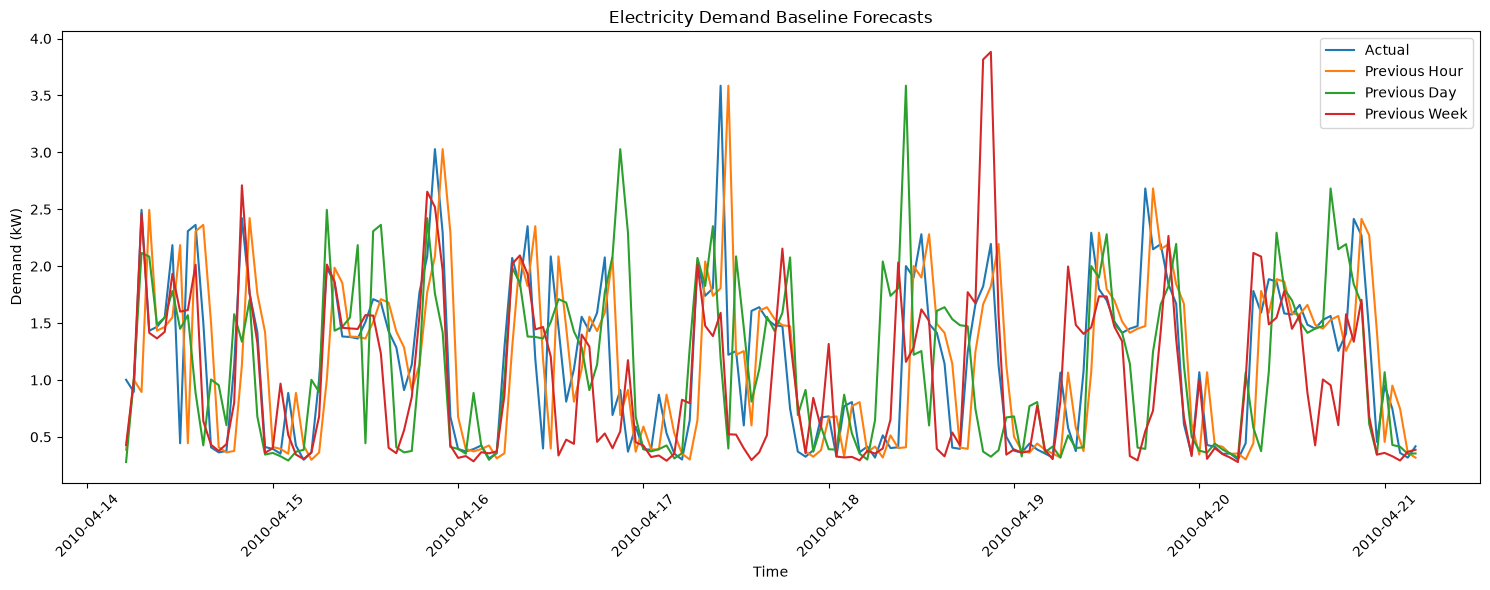

In [182]:
import matplotlib.pyplot as plt

hours_to_plot = 168

plt.figure(figsize=(15, 6))

plt.plot(
    y_test.index[:hours_to_plot],
    y_test.iloc[:hours_to_plot],
    label="Actual"
)

plt.plot(
    baseline_1h.index[:hours_to_plot],
    baseline_1h.iloc[:hours_to_plot],
    label="Previous Hour"
)

plt.plot(
    baseline_24h.index[:hours_to_plot],
    baseline_24h.iloc[:hours_to_plot],
    label="Previous Day"
)

plt.plot(
    baseline_168h.index[:hours_to_plot],
    baseline_168h.iloc[:hours_to_plot],
    label="Previous Week"
)

plt.title("Electricity Demand Baseline Forecasts")

plt.xlabel("Time")
plt.ylabel("Demand (kW)")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [183]:
from src.evaluation.metrics import calculate_metrics

# Stage 07 — First ML Model

## Linear_regression

In [184]:
from src.models.linear_regression import create_linear_regression_model

In [185]:
linear_model = create_linear_regression_model()

print(linear_model)

LinearRegression()


In [186]:
linear_model.fit(
    X_train,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](32,)","[-0.01,-0.01,-0. ,..., 0.15, 0.13,-0.08]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](32,)","['hour','day_of_week','day_of_month',...,'rolling_std_48h', 'rolling_mean_168h','rolling_std_168h']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.225
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,32
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,31


# Generate validation prediction

In [187]:
y_val_pred_linear = linear_model.predict(
    X_val
)

In [188]:
linear_val_metrics = calculate_metrics(
    y_val,
    y_val_pred_linear
)

print("Linear Regression - Validation")
print(linear_val_metrics)

Linear Regression - Validation
{'MAE': 0.3983950380291089, 'RMSE': np.float64(0.5656001636606101), 'MAPE': np.float64(45.094971294551094), 'sMAPE': np.float64(35.32408506132107), 'R2': 0.5979459719320225}


In [189]:
# Compare Linear Regression against the baseline

linear_comparison = pd.DataFrame([
    {
        "Model": "Previous Hour Baseline",
        **calculate_metrics(
            y_val,
            X_val["lag_1h"]
        )
    },
    {
        "Model": "Linear Regression",
        **linear_val_metrics
    }
])

display(linear_comparison)

,Model,MAE,RMSE,MAPE,sMAPE,R2
0,Previous Hour Baseline,0.464315,0.692123,45.414349,37.976518,0.397951
1,Linear Regression,0.398395,0.565600,45.094971,35.324085,0.597946


In [190]:
from src.models.linear_regression import create_linear_regression_model

In [191]:
linear_model = create_linear_regression_model()

linear_model.fit(
    X_train,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](32,)","[-0.01,-0.01,-0. ,..., 0.15, 0.13,-0.08]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](32,)","['hour','day_of_week','day_of_month',...,'rolling_std_48h', 'rolling_mean_168h','rolling_std_168h']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.225
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,32
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,31


In [192]:
y_val_pred_linear = linear_model.predict(
    X_val
)

In [193]:
linear_val_metrics = calculate_metrics(
    y_val,
    y_val_pred_linear
)

print(linear_val_metrics)

{'MAE': 0.3983950380291089, 'RMSE': np.float64(0.5656001636606101), 'MAPE': np.float64(45.094971294551094), 'sMAPE': np.float64(35.32408506132107), 'R2': 0.5979459719320225}


In [194]:
linear_comparison = pd.DataFrame([
    {
        "Model": "Previous Hour Baseline",
        **calculate_metrics(
            y_val,
            X_val["lag_1h"]
        )
    },
    {
        "Model": "Linear Regression",
        **linear_val_metrics
    }
])

display(linear_comparison)

,Model,MAE,RMSE,MAPE,sMAPE,R2
0,Previous Hour Baseline,0.464315,0.692123,45.414349,37.976518,0.397951
1,Linear Regression,0.398395,0.565600,45.094971,35.324085,0.597946


In [195]:
# Create prediction dataframe
linear_predictions = pd.DataFrame({
    "actual": y_val.values,
    "predicted": y_val_pred_linear
})

linear_predictions["error"] = (
    linear_predictions["actual"]
    - linear_predictions["predicted"]
)

linear_predictions["absolute_error"] = (
    linear_predictions["error"].abs()
)

linear_predictions.head()

,actual,predicted,error,absolute_error
0,0.317633,0.475632,-0.157999,0.157999
1,0.645567,0.422485,0.223082,0.223082
2,0.365233,0.616056,-0.250823,0.250823
3,0.357333,0.502822,-0.145488,0.145488
4,0.316767,0.755163,-0.438396,0.438396


In [196]:
# Calculate error statistics
print(
    linear_predictions[
        ["error", "absolute_error"]
    ].describe()
)

             error  absolute_error
count  4898.000000     4898.000000
mean      0.004926        0.398395
std       0.565636        0.401519
min      -2.122002        0.000111
25%      -0.308321        0.105189
50%      -0.031577        0.273856
75%       0.223849        0.571173
max       3.844294        3.844294


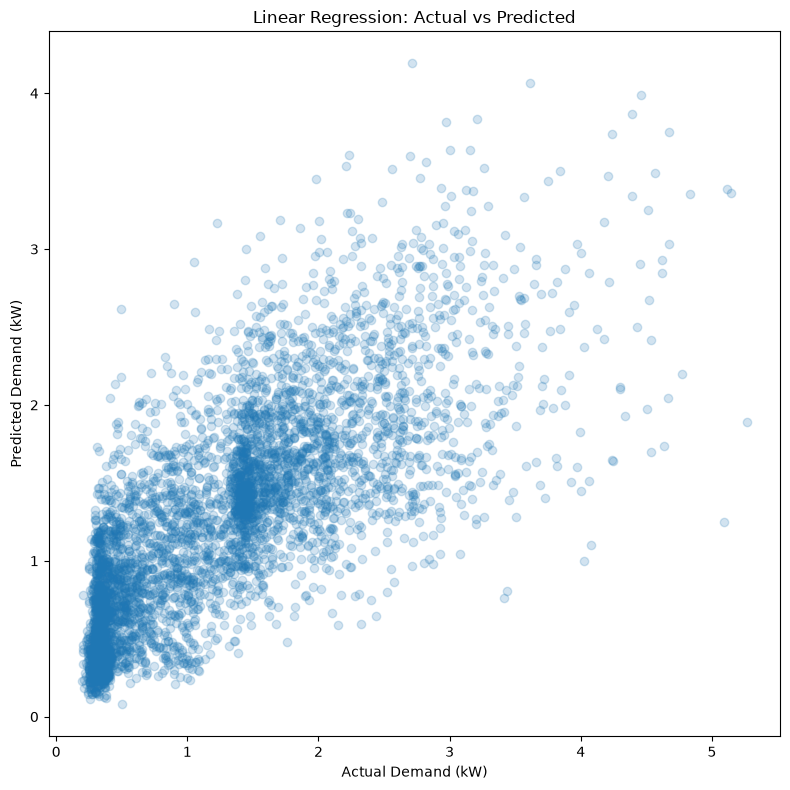

In [197]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

plt.scatter(
    linear_predictions["actual"],
    linear_predictions["predicted"],
    alpha=0.2
)

plt.xlabel("Actual Demand (kW)")
plt.ylabel("Predicted Demand (kW)")
plt.title("Linear Regression: Actual vs Predicted")

plt.tight_layout()
plt.show()

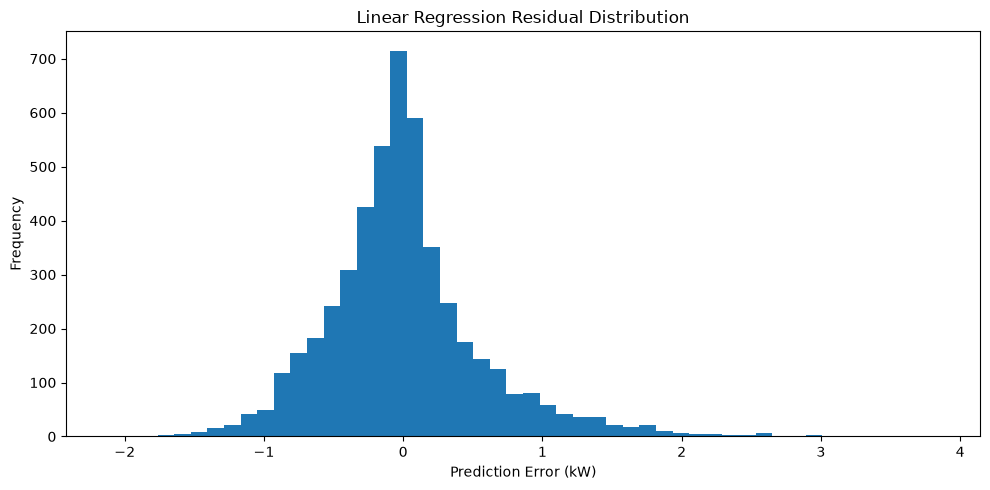

In [198]:
# Residual distribution

plt.figure(figsize=(10, 5))

plt.hist(
    linear_predictions["error"],
    bins=50
)

plt.xlabel("Prediction Error (kW)")
plt.ylabel("Frequency")
plt.title("Linear Regression Residual Distribution")

plt.tight_layout()
plt.show()

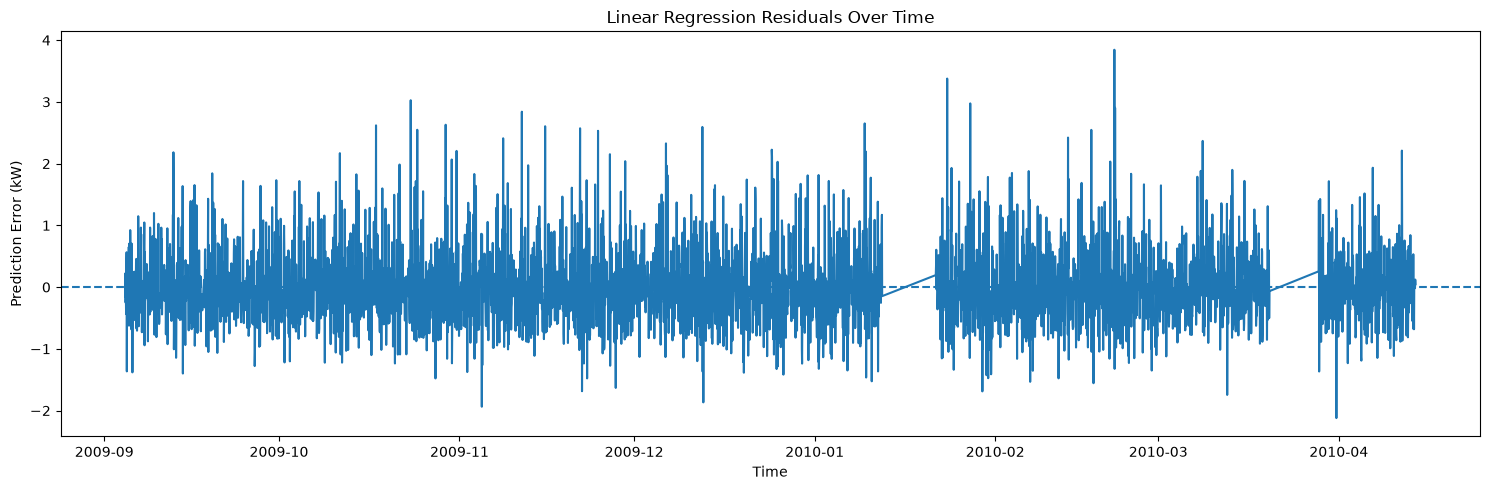

In [199]:
# Residuals over time
plt.figure(figsize=(15, 5))

plt.plot(
    y_val.index,
    linear_predictions["error"]
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Time")
plt.ylabel("Prediction Error (kW)")
plt.title("Linear Regression Residuals Over Time")

plt.tight_layout()
plt.show()

In [200]:
# Check performance on high-demand periods
peak_threshold = y_train.quantile(0.95)

print(
    "Training 95th percentile:",
    peak_threshold
)

Training 95th percentile: 2.9539133333333307


In [201]:
# Evaluate Linear Regression during peaks
peak_mask = y_val >= peak_threshold

print(
    "Validation peak observations:",
    peak_mask.sum()
)

print(
    "Validation peak percentage:",
    peak_mask.mean() * 100
)

Validation peak observations: 225
Validation peak percentage: 4.593711719069008


In [202]:
peak_metrics = calculate_metrics(
    y_val[peak_mask],
    y_val_pred_linear[peak_mask]
)

print("Linear Regression - Peak Performance")
print(peak_metrics)

Linear Regression - Peak Performance
{'MAE': 1.2365966408108968, 'RMSE': np.float64(1.4305480035279157), 'MAPE': np.float64(34.43314864832982), 'sMAPE': np.float64(44.44261570293517), 'R2': -6.406434017580809}


In [203]:
# Compare normal vs peak performance
normal_mask = y_val < peak_threshold

normal_metrics = calculate_metrics(
    y_val[normal_mask],
    y_val_pred_linear[normal_mask]
)

comparison = pd.DataFrame([
    {
        "Segment": "Normal Demand",
        **normal_metrics
    },
    {
        "Segment": "Peak Demand",
        **peak_metrics
    }
])

display(comparison)

,Segment,MAE,RMSE,MAPE,sMAPE,R2
0,Normal Demand,0.358037,0.486592,45.608327,34.885037,0.575344
1,Peak Demand,1.236597,1.430548,34.433149,44.442616,-6.406434


In [204]:
import joblib
from pathlib import Path

MODEL_DIR = Path(PROJECT_ROOT) / "models"
MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

model_path = MODEL_DIR / "linear_regression.joblib"

joblib.dump(
    linear_model,
    model_path
)

print("Model saved to:", model_path)

Model saved to: c:\Users\sayum\Desktop\smartenergy-ai\models\linear_regression.joblib


# Stage 08 — Random Forest

In [205]:
# Import the model
from src.models.random_forest import (
    create_random_forest_model
)

In [206]:
rf_model = create_random_forest_model()

print(rf_model)

RandomForestRegressor(max_depth=20, min_samples_leaf=2, n_estimators=200,
                      n_jobs=-1, random_state=42)


In [207]:
# Train Random Forest

rf_model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max

In [208]:
# Validation predictions
y_val_pred_rf = rf_model.predict(
    X_val
)

In [209]:
rf_val_metrics = calculate_metrics(
    y_val,
    y_val_pred_rf
)

print("Random Forest - Validation")
print(rf_val_metrics)

Random Forest - Validation
{'MAE': 0.36769003116894106, 'RMSE': np.float64(0.5340888364141884), 'MAPE': np.float64(39.91521815479279), 'sMAPE': np.float64(31.611946976615958), 'R2': 0.6414973539920095}


In [210]:
# Compare all three models

model_comparison = pd.DataFrame([
    {
        "Model": "Previous Hour Baseline",
        **calculate_metrics(
            y_val,
            X_val["lag_1h"]
        )
    },
    {
        "Model": "Linear Regression",
        **linear_val_metrics
    },
    {
        "Model": "Random Forest",
        **rf_val_metrics
    }
])

display(
    model_comparison.sort_values(
        "MAE"
    )
)

,Model,MAE,RMSE,MAPE,sMAPE,R2
2,Random Forest,0.367690,0.534089,39.915218,31.611947,0.641497
1,Linear Regression,0.398395,0.565600,45.094971,35.324085,0.597946
0,Previous Hour Baseline,0.464315,0.692123,45.414349,37.976518,0.397951


In [211]:
rf_peak_metrics = calculate_metrics(
    y_val[peak_mask],
    y_val_pred_rf[peak_mask]
)

print("Random Forest - Peak Performance")
print(rf_peak_metrics)

Random Forest - Peak Performance
{'MAE': 1.1299022863488573, 'RMSE': np.float64(1.329154384356299), 'MAPE': np.float64(31.3190166538742), 'sMAPE': np.float64(39.73493445805246), 'R2': -5.393742525204275}


In [212]:
peak_comparison = pd.DataFrame([
    {
        "Model": "Linear Regression",
        **peak_metrics
    },
    {
        "Model": "Random Forest",
        **rf_peak_metrics
    }
])

display(peak_comparison)

,Model,MAE,RMSE,MAPE,sMAPE,R2
0,Linear Regression,1.236597,1.430548,34.433149,44.442616,-6.406434
1,Random Forest,1.129902,1.329154,31.319017,39.734934,-5.393743


In [214]:
# Random Forest feature importance

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

display(
    feature_importance.head(15)
)

,feature,importance
12,lag_1h,0.561515
19,lag_168h,0.036894
16,lag_24h,0.027159
9,hour_cos,0.024412
15,lag_12h,0.022200
6,is_night,0.021068
17,lag_48h,0.020096
18,lag_72h,0.020093
8,hour_sin,0.019650
13,lag_2h,0.019147


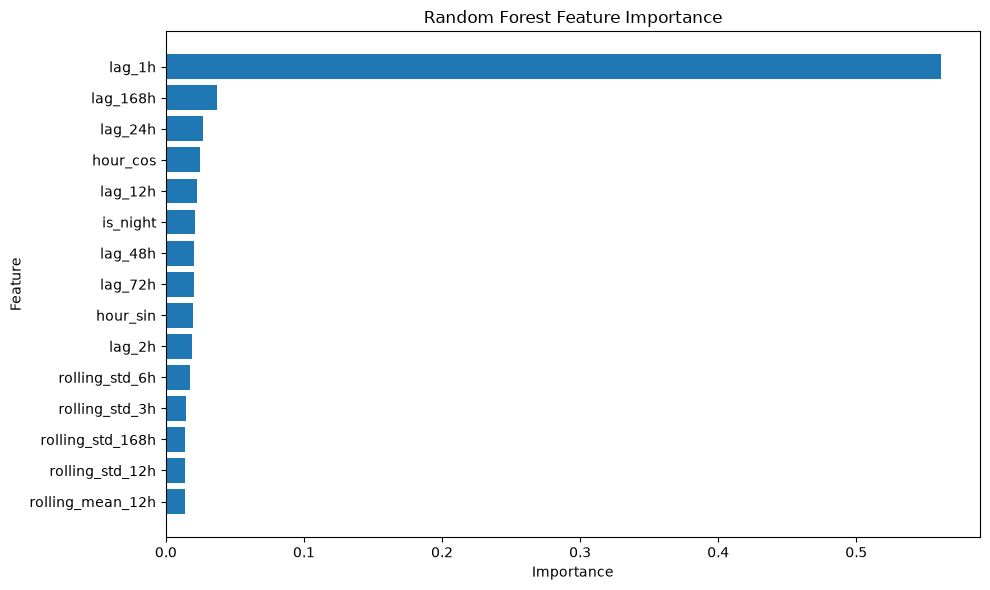

In [215]:
# Create the feature-importance chart
import matplotlib.pyplot as plt

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()

In [216]:
# Check Random Forest performance
print("========== RANDOM FOREST VALIDATION ==========")
print(rf_val_metrics)

========== RANDOM FOREST VALIDATION ==========
{'MAE': 0.36769003116894106, 'RMSE': np.float64(0.5340888364141884), 'MAPE': np.float64(39.91521815479279), 'sMAPE': np.float64(31.611946976615958), 'R2': 0.6414973539920095}


In [217]:
print("========== RANDOM FOREST PEAK PERFORMANCE ==========")
print(rf_peak_metrics)

========== RANDOM FOREST PEAK PERFORMANCE ==========
{'MAE': 1.1299022863488573, 'RMSE': np.float64(1.329154384356299), 'MAPE': np.float64(31.3190166538742), 'sMAPE': np.float64(39.73493445805246), 'R2': -5.393742525204275}


In [218]:
# Create the overall model comparison
model_comparison = pd.DataFrame([
    {
        "Model": "Previous Hour Baseline",
        **calculate_metrics(
            y_val,
            X_val["lag_1h"]
        )
    },
    {
        "Model": "Linear Regression",
        **linear_val_metrics
    },
    {
        "Model": "Random Forest",
        **rf_val_metrics
    }
])

model_comparison = model_comparison.sort_values(
    by="MAE",
    ascending=True
).reset_index(drop=True)

display(model_comparison)

,Model,MAE,RMSE,MAPE,sMAPE,R2
0,Random Forest,0.367690,0.534089,39.915218,31.611947,0.641497
1,Linear Regression,0.398395,0.565600,45.094971,35.324085,0.597946
2,Previous Hour Baseline,0.464315,0.692123,45.414349,37.976518,0.397951


In [220]:
# Compare peak performance
peak_comparison = pd.DataFrame([
    {
        "Model": "Linear Regression",
        **peak_metrics
    },
    {
        "Model": "Random Forest",
        **rf_peak_metrics
    }
])

peak_comparison = peak_comparison.sort_values(
    by="MAE",
    ascending=True
).reset_index(drop=True)

display(peak_comparison)

,Model,MAE,RMSE,MAPE,sMAPE,R2
0,Random Forest,1.129902,1.329154,31.319017,39.734934,-5.393743
1,Linear Regression,1.236597,1.430548,34.433149,44.442616,-6.406434


In [221]:
from src.models.random_forest import create_random_forest_model

In [222]:
from src.models.random_forest import create_random_forest_model


def test_create_random_forest_model():
    model = create_random_forest_model()

    assert model is not None
    assert model.__class__.__name__ == "RandomForestRegressor"